# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [4]:
# seu código aqui
# carregando os dados e tratando se necessário
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [7]:
# Pelo visto na base o peso esta como um objeto então iremos converter o peso para um float

#Primeiro trocaremos o separador de virgula para ponto
base['weight'] = base['weight'].str.replace(',', '.')

# Trocando o separador agora conseguimos converter
base['weight'] = base['weight'].astype(float)

In [17]:
#Convertendo a altura de int para float
base['height'] = base['height'].astype(float)

In [18]:
#Testando para verficiar se tipo foi alterado
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  float64
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 781.4 KB


In [11]:
# Verificando se existem dados negativos ou faltantes
base.isnull().sum()

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64

In [13]:
# Verificando outliers
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


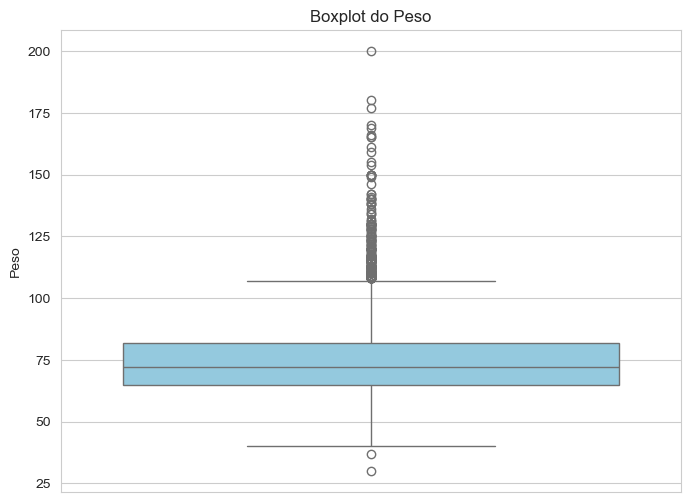

In [15]:
# Boxplot do peso 
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=base, y='weight', color='skyblue')
plt.title('Boxplot do Peso')
plt.ylabel('Peso')
plt.show()

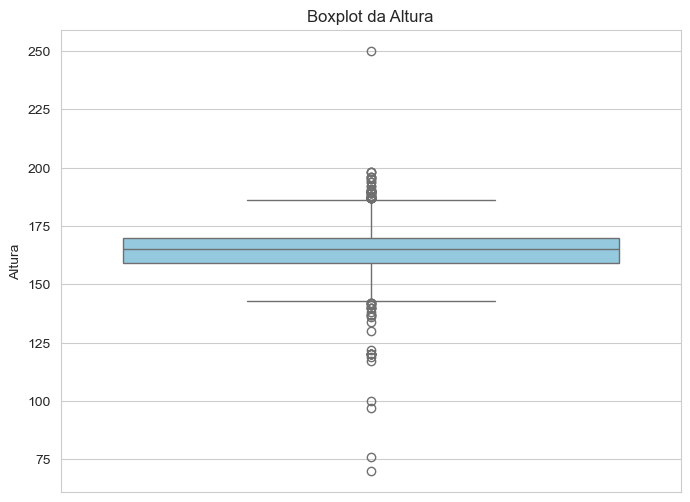

In [19]:
# Boxplot da altura

sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=base, y='height', color='skyblue')
plt.title('Boxplot da Altura')
plt.ylabel('Altura')
plt.show()

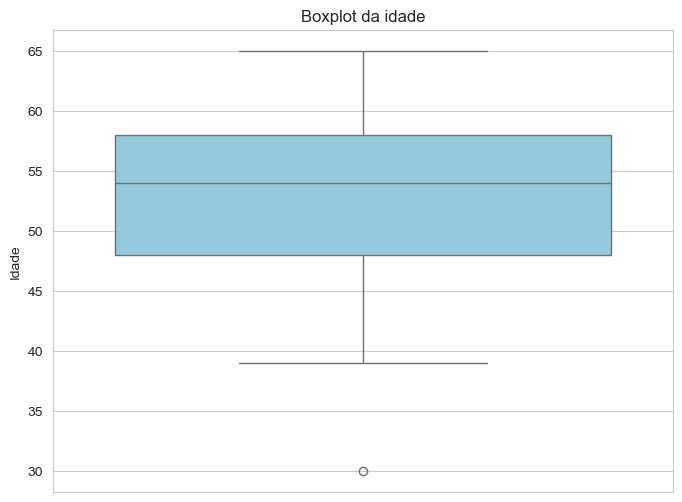

In [20]:
#boxplot da idade
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=base, y='age', color='skyblue')
plt.title('Boxplot da idade')
plt.ylabel('Idade')
plt.show()

In [24]:
# Os valores de peso e altura possuem muitos ouliers sendo assim necessário o tratamento
colunas = ['weight', 'height']

# Tratar outliers
for col in colunas:
    Q1 = base[col].quantile(0.25)
    Q3 = base[col].quantile(0.75)
    IQR = Q3 - Q1
    base[col] = base[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

#Salvando o df agora sem os outliers
base.to_csv('cardio_sem_outliers.csv')

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


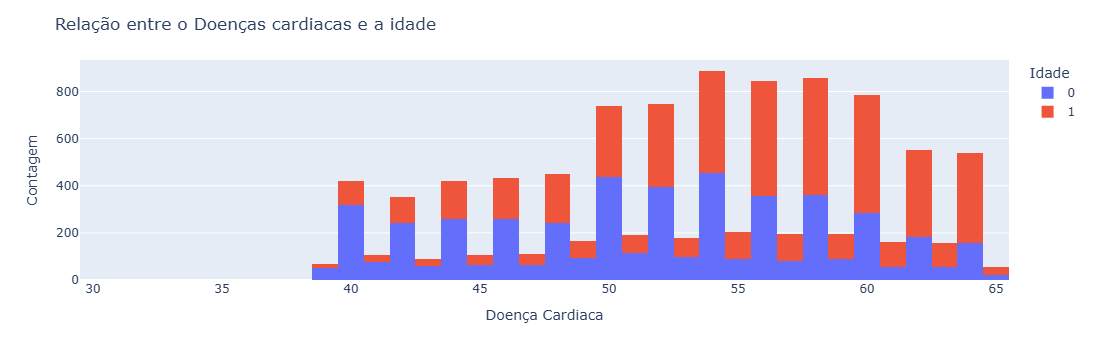

In [31]:
# seu código aqui
#Gráfico 1: cardio_desease pela idade

fig = px.histogram(base, x='age', color='cardio_disease', barmode='stack')

fig.update_layout(title='Relação entre o Doenças cardiacas e a idade',
                  xaxis_title='Doença Cardiaca',
                  yaxis_title='Contagem',
                  legend_title='Idade')

fig.show() 

**Neste gráficos podemos visualizar que o indice de doenças cardiacas aumenta conforme a idade**

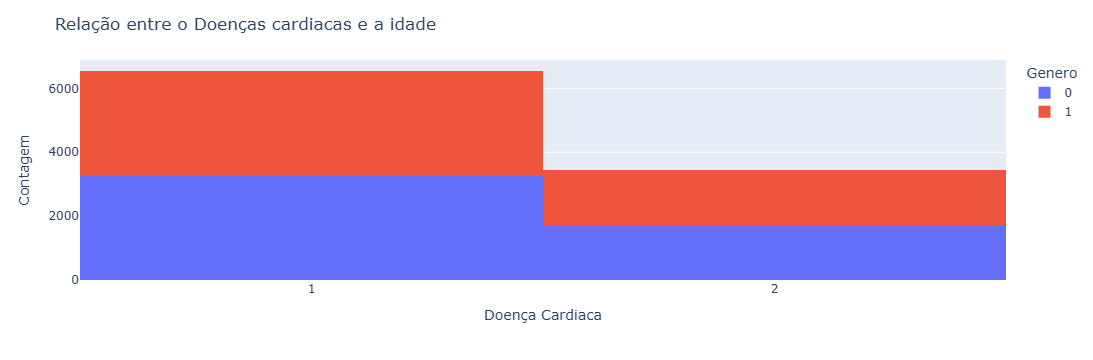

In [33]:
# Relação de doenças cardicas e o genêro
fig = px.histogram(base, x='gender', color='cardio_disease', barmode='stack')

fig.update_layout(title='Relação entre o Doenças cardiacas e a idade',
                  xaxis_title='Doença Cardiaca',
                  yaxis_title='Contagem',
                  legend_title='Genero')

fig.show() 

**Agora podemos constatar que os maiores indices de doenças cardiacas estão no genêro masculino**

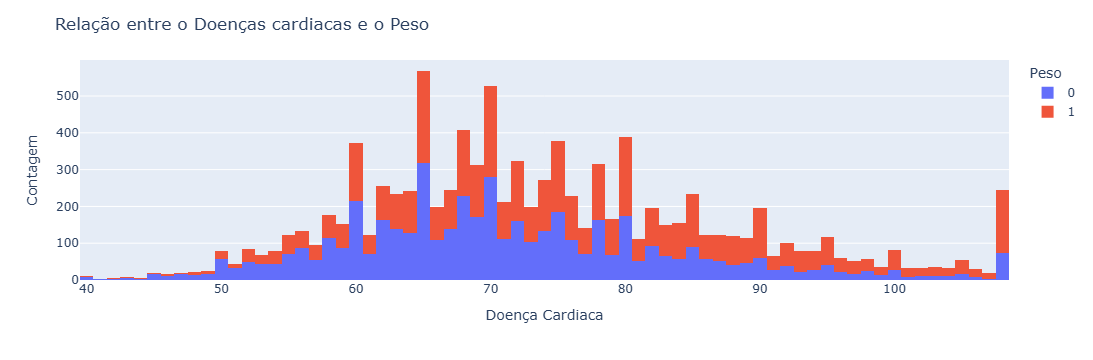

In [35]:
# Relação entre doenças cardiacas e o peso

fig = px.histogram(base, x='weight', color='cardio_disease', barmode='stack')

fig.update_layout(title='Relação entre o Doenças cardiacas e o Peso',
                  xaxis_title='Doença Cardiaca',
                  yaxis_title='Contagem',
                  legend_title='Peso')

fig.show() 

**Podemos notar também que quanto mais pesada a pessoa maiores as chances de ela ter uma doença cardiaca**

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



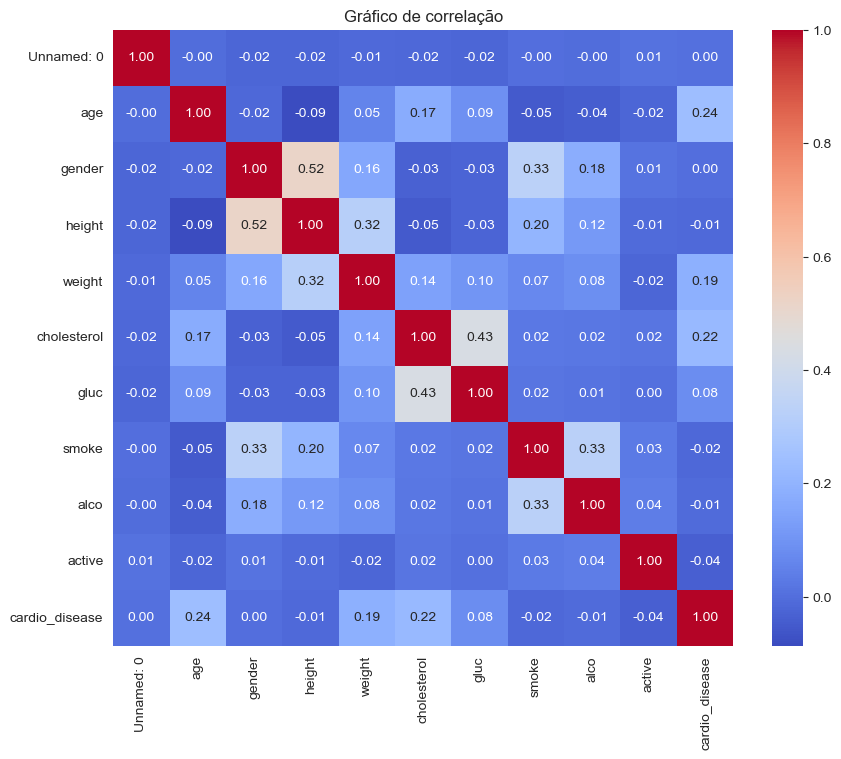

In [37]:
# seu código aqui

base = pd.read_csv('cardio_sem_outliers.csv')

correlacao = base.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlacao,annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Gráfico de correlação')
plt.show()

**Aqui notamos algumas correlações fortes entre a altura e da glicose com o cholesterol, também podemos notar uma relação do consumo de alcool e cigarro, entre o peso e a altura e uma correlação bem fraca entre as doenças cardiacas e a idade peso e níveis de colesterol**

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [39]:
# seu código aqui
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = base.drop('cardio_disease', axis=1)  # X contém todas as colunas exceto 'cardio_desease'
Y = base['cardio_disease']  # Y contém apenas a coluna 'cardio_desease'

In [40]:
base['cardio_disease'].value_counts()

cardio_disease
1    5031
0    4969
Name: count, dtype: int64

## A

In [41]:
# Separando em treino em teste com uma base de 80% para treino e 20% para teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## B

In [42]:
# Eu ainda não padronizei os valores a unica coisa feita foi um tratamento para remoção dos outliers então vamos a padronização

# criando um inicializador StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

## C

In [43]:
# Os dados também não estão balanceados então vamos ao balanceamento

smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

## D

In [44]:
X_train_balanced

array([[ 1.4692775 ,  0.10037973, -0.73138185, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-1.19499359, -0.19393504,  1.36727483, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-1.15724427,  1.4247962 , -0.73138185, ..., -0.31328402,
        -0.24037742, -1.96927621],
       ...,
       [-0.39404866,  0.890114  ,  1.36727483, ..., -0.31328402,
        -0.24037742,  0.50780078],
       [-0.48114926, -1.40902517,  1.36727483, ...,  3.19199173,
        -0.24037742,  0.50780078],
       [-0.40560457, -1.19514563, -0.73138185, ..., -0.31328402,
        -0.24037742,  0.50780078]], shape=(8064, 10))

In [45]:
Y_train_balanced

0       0
1       0
2       1
3       1
4       0
       ..
8059    0
8060    0
8061    0
8062    0
8063    0
Name: cardio_disease, Length: 8064, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [46]:
# seu código aqui
# A Treinando o modelo
logistic_cardio_desease = LogisticRegression(random_state = 0)

In [47]:
logistic_cardio_desease.fit(X_train_balanced,Y_train_balanced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
# B trazendo intercept e coef
# Intercept
logistic_cardio_desease.intercept_

array([0.01387406])

In [49]:
#Coef
logistic_cardio_desease.coef_

array([[ 0.03285398,  0.43677488,  0.01780493, -0.10129602,  0.35822046,
         0.40573895, -0.07389451, -0.02706109, -0.01036858, -0.07155225]])

In [51]:
#C  Trazendo as métricas do treinamento e avaliando
previsoes = logistic_cardio_desease.predict(X_train_balanced)

In [52]:
relatorio = classification_report(Y_train_balanced, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.66      0.64      4032
           1       0.64      0.61      0.63      4032

    accuracy                           0.64      8064
   macro avg       0.64      0.64      0.64      8064
weighted avg       0.64      0.64      0.64      8064



**Na minha opinião o modelo não faria previsões tão boas devido a todos os valores estarem muito proximos do 0,5 pois valores considerados bom são valores mais proximos de 0,8**

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [53]:
# seu código aqui
# A Aplicando ao modelo de testes
Y_pred_test = logistic_cardio_desease.predict(X_test)

In [54]:
relatorio = classification_report(Y_test, Y_pred_test)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67      1001
           1       0.67      0.61      0.64       999

    accuracy                           0.65      2000
   macro avg       0.66      0.65      0.65      2000
weighted avg       0.66      0.65      0.65      2000



## B

**As métricas do modelo aplicadas na base de testes obtiveram uma leve melhora com o recall chegando a 0.70 e os outros dados como F1 score chegando mais proximo de 0,70 com 0,67**

## C

In [55]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_test)

# Calculando o AUC
roc_auc = roc_auc_score(Y_test, Y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.65


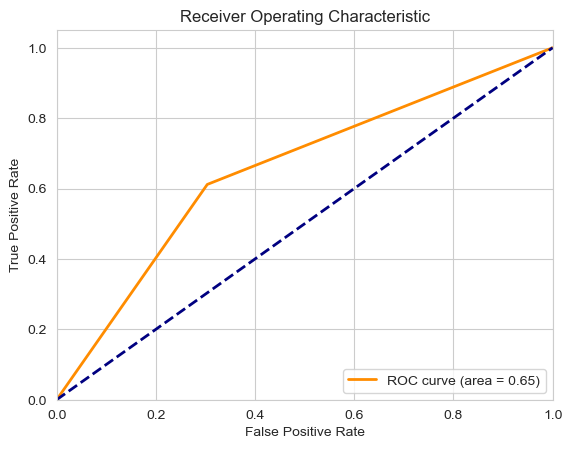

In [56]:
#Plotando o gráfico de ROC

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

**Neste gráfico podemos analisar que a área da curva ROC é de 0.65 sendo muito próxima do 0.50 oque não traria boas previsões considerando que na aula foi dito que valores bons seriam algo proximo de 0.70 0.80**

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



## A

**A regressão logistica apesar do nome regressão se trata de um problema de classificação porque prevê categorias como sim ou não ao invés de valores continuos, ela calcula a probabilidade de um evento ocorrer e então classfica o resultado**

## B

**A regressão logistica é um modelo de classficação porque ela não prevê valores continuos e sim categorias como sim ou não, calculando a sua probabilidade de ocorrer e classificando o resultado**

## C

**Ambas são modelos de aprendizados supervisionado de machine learning, também são baseadas em modelos lineares por assumirem uma relação linear entre suas variáveis e também possuem a finalidade de predição o que quer dizer que elas são utilizar a fim de se prever alguma coisa seja um numero ou a probabilidade de um evento acontecer ou não**